# Mouse-brain Perturb-seq with causarray 0.1.1: L4-5 IT Glut

This notebook runs causarray on one cell type of the mouse-brain CRISPR screen,
L4-5 IT CTX Glut (58 perturbations, 15,135 non-targeting control cells), from
counts to biological readouts. Every step is a function in `pipeline.py`, and
section 7 runs the same steps for every cell type.

**What we learn from this cell type**

* **56 of 58 perturbations change expression**, with 9,981 hits in total. How many hits a perturbation gets does not track how many cells it has (Spearman 0.02), so the counts reflect how strongly each perturbation acts.
* **Three perturbations dominate: Prpf6 (1,887 hits), Ppp2r1a (1,486) and Tpr (1,457).** Prpf6 and Tpr up-regulate genes of their own machinery (Prpf6, a spliceosome component: mRNA splicing; Tpr, a nuclear-pore protein: transcription and RNA metabolism), and all three down-regulate neuronal genes; Ppp2r1a's up-regulated genes have no clear theme.
* **The proteasome subunits Pomp, Psmc1 and Psmc5 give the most similar responses** (correlation of effects 0.35–0.49), as expected for three parts of one complex.
* **A few genes respond to many perturbations**: activity-regulated Bdnf and Adcyap1 go up in most of the 9–10 perturbations that hit them, while Atp1a1, Scube1 and Ahi1 go down, suggesting a shared response of these neurons to disruption.
* **The results can be trusted on this cell type.** On fake perturbations made from control cells, causarray makes 14 false hits over 30 fake arms (Wilcoxon: 99), and its statistics are close to N(0, 1) (SD 1.03).

Words used below:

* **arm**: one group of cells. Each test compares two arms, the controls and
  the cells carrying one perturbation (Tpr, Prpf6, ...).
* **hit** (discovery): a gene–perturbation pair with BH-adjusted p < 0.05; BH is
  applied within each perturbation.
* **tau**: causarray's log fold change (natural log) of a gene's expression,
  perturbed versus control, after adjusting for the latent factors.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import causarray
import pipeline as pl
from causarray import estimate_propensity_scores, summarize_propensity_scores, plot_propensity_scores

print('causarray', causarray.__version__)
TAG = 'L45Glut'            # results go to results/L45Glut/
Q = pl.Q                    # FDR level, 0.05
BLUE, ORANGE, PURPLE, GREY = '#2a78d6', '#eb6834', '#8e44ad', '#c8c7c2'

causarray 0.1.1


## 1. The pipeline for one cell type

Each step caches its output under `results/L45Glut/` and is skipped when the
cache exists, so the cells below only load results; with no cache the same
calls compute everything.

| step | function | output |
|---|---|---|
| select the cell type | `pl.subset_cell_type(src, '005 L4-5 IT CTX Glut', 'L45Glut')` | `data/L45Glut.h5ad` |
| counts and designs | `pl.load_inputs(tag)` | genes seen in ≥ 50 cells |
| latent factors | `pl.fit_factors(tag, ...)` | `gcate.pkl`, rank r = 8 |
| effects | `pl.run_lfc(tag, ...)` | `lfc.csv` (all controls + 10 perturbations per batch) |
| calibration check | `pl.run_null(tag, ..., seed)` | `null/seed*.csv` |
| Wilcoxon reference | `pl.run_wilcoxon(tag)` | `wilcoxon.h5ad` (crispyx) |

Three settings are fixed for all cell types:

* **rank r = 8** latent factors, chosen by JIC on this cell type and reused to save time;
* **`min_counts = 20`**: a gene is tested only if the smaller arm is expected to
  hold at least about 20 counts (the package default is 5; section 4 shows why);
* **propensity check**: before each `LFC` call, `pl._propensity` flags any arm
  whose propensity weights concentrate and adjusts that arm only (section 2).

In [2]:
Y, A, X, X_A = pl.load_inputs(TAG)
res_2 = pl.fit_factors(TAG, Y, X, A)
df = pl.run_lfc(TAG, Y, A, X, X_A, res_2)

n_pert = A.sum(0)
print(f'{Y.shape[0]:,} cells x {Y.shape[1]:,} genes; {A.shape[1]} perturbations; '
      f'{int((A.sum(1) == 0).sum()):,} controls')
print(f'cells per perturbation: min {n_pert.min():.0f}, median {n_pert.median():.0f}, max {n_pert.max():.0f}')

22,396 cells x 14,227 genes; 58 perturbations; 15,135 controls
cells per perturbation: min 68, median 122, max 227


## 2. Check the propensity model before reading any effect

causarray reweights cells by the propensity score, the estimated probability
that a cell carries a given perturbation, from its library size and latent
factors. If these covariates nearly separate an arm from the controls, a few
cells get huge weights and dominate that arm's estimates. Three numbers per
perturbation catch this:

* **AUC**: how well the scores separate the two arms (0.5: not at all; above
  about 0.9 is a warning);
* **overlap**: the area the two score histograms share (1: identical; below about
  0.3 is a warning);
* **treated ESS fraction**: how many perturbed cells effectively remain after
  weighting (near 1 is good; below 0.5 means a few cells dominate).

**Library size is a judgement call.** It could be a confounder (capture depth,
cell quality) or an effect of the perturbation (total RNA), and the data cannot
tell which. The rule in the `LFC` documentation is to keep it while every arm
stays supported. `pl._propensity` applies that rule automatically: for a flagged
arm it drops the covariate most imbalanced against the controls (library size or
a factor) until support recovers, and leaves the other arms untouched.

The scores themselves are small, about 0.01, because controls outnumber the
perturbed cells about 100 to 1. That is expected; a rule like "scores must lie
in [0.05, 0.95]" is meant for balanced designs.

median propensity score of perturbed cells: 0.009
all 58 perturbations: AUC <= 0.74, overlap >= 0.56, treated ESS fraction >= 0.36
perturbations flagged by the automatic check: 1 of 58


,n_treated,auc,overlap_ratio,ess_treated_fraction
treatment,,,,
Tpr,91,0.736,0.560,0.363
Pomp,68,0.672,0.679,0.771
Srsf1,188,0.679,0.699,0.874
Prpf6,78,0.674,0.701,0.748
Sin3a,109,0.667,0.729,0.753


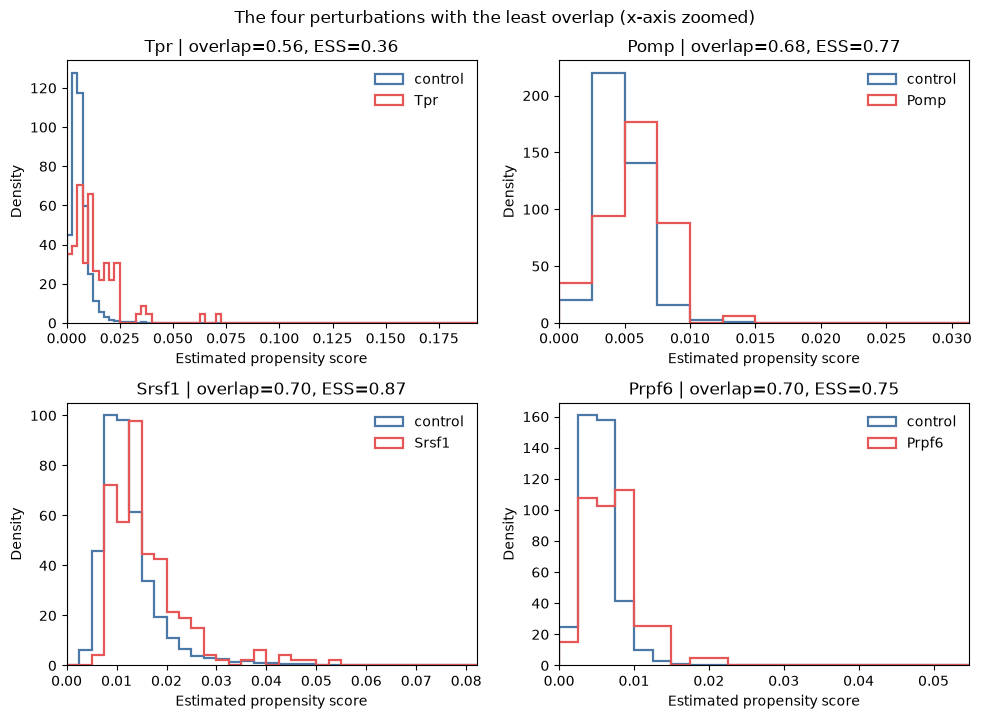

In [3]:
W_A = np.c_[X_A, res_2['U']]
pi = estimate_propensity_scores(A, W_A, K=1, C=1.0, class_weight=None, clip=None, random_state=0)
PS_BINS = 400                # scores sit in [0, 0.1]; 40 default bins would lump them together
ps = summarize_propensity_scores(A, pi, clip_bounds=None, bins=PS_BINS).set_index('treatment')
_, flagged = pl._propensity(A, W_A)

print(f"median propensity score of perturbed cells: {np.median(pi[A.to_numpy() == 1]):.3f}")
print(f"all {len(ps)} perturbations: AUC <= {ps['auc'].max():.2f}, "
      f"overlap >= {ps['overlap_ratio'].min():.2f}, treated ESS fraction >= {ps['ess_treated_fraction'].min():.2f}")
print(f'perturbations flagged by the automatic check: {len(flagged)} of {A.shape[1]}')
display(ps.nsmallest(5, 'overlap_ratio')[['n_treated', 'auc', 'overlap_ratio', 'ess_treated_fraction']].round(3))

show = ps.nsmallest(4, 'overlap_ratio').index.tolist()
fig, axes, _ = plot_propensity_scores(A, pi, treatments=show, clip_bounds=None, bins=PS_BINS,
                                      overlap_bounds=(0, 1))
A_np, ctrl = A.to_numpy(dtype=float), A.to_numpy().sum(1) == 0
for ax, t in zip(np.asarray(axes).ravel(), show):
    j = A.columns.get_loc(t)
    ax.set_xlim(0, 1.05 * pi[ctrl | (A_np[:, j] == 1), j].max())
fig.suptitle('The four perturbations with the least overlap (x-axis zoomed)', y=1.02)
plt.show()

The fit above uses all 58 perturbations at once, as an overview. `LFC` itself
fits the propensity model inside each batch (all controls plus 10
perturbations), and the pipeline runs its check there. The arms it adjusted are
written next to the batch results:

In [4]:
from pathlib import Path
reports = sorted(Path(f'results/{TAG}/lfc_batches').glob('batch_*_propensity.csv'))
adjusted = pd.concat([pd.read_csv(f) for f in reports], ignore_index=True) if reports else pd.DataFrame()
print(f'arms adjusted inside their LFC batch: {len(adjusted)} of {A.shape[1]}')
if len(adjusted):
    display(adjusted.set_index('treatment')[
        ['dropped', 'auc_all', 'auc_chosen', 'ess_treated_fraction_all', 'ess_treated_fraction_chosen']].round(3))

arms adjusted inside their LFC batch: 1 of 58


,dropped,auc_all,auc_chosen,ess_treated_fraction_all,ess_treated_fraction_chosen
treatment,,,,,
Tpr,log_library_size,0.736,0.579,0.363,0.998


**Conclusion.** The scores are small (median 0.009 for perturbed cells), as expected with about one perturbed cell per 100 controls, and no perturbation is separated from the controls: AUC is at most 0.74 and overlap at least 0.56. One perturbation fails the weighting check: **Tpr**, whose treated ESS fraction is 0.36, so its weights rest on about a third of its cells. For Tpr alone the check drops library size, the covariate most imbalanced between Tpr and the controls, and its ESS fraction returns to 1.0. Tpr cells have the largest libraries of all arms (18% above the controls, where the median arm is at 98%); whether that is Tpr knockdown raising total RNA or a technical difference, these data cannot say, which is why the choice is made only where support fails. The other 57 perturbations keep library size and every factor.

## 3. Estimate the effects

`pl.run_lfc` calls `LFC` on all controls plus 10 perturbations at a time and
stacks the batches into one table, one row per gene and perturbation. The
columns used most are `tau` (log fold change), `padj` (BH-adjusted p-value),
`count_treated` (total counts of the gene in the perturbed arm) and
`mean_control` (mean counts per control cell).

,L45Glut
gene x perturbation pairs tested,565064
hits,9981
perturbations with >= 1 hit,56 / 58
hits that are down-regulated,24%
hits with zero counts in the perturbed arm,0
median |tau| of hits,0.36


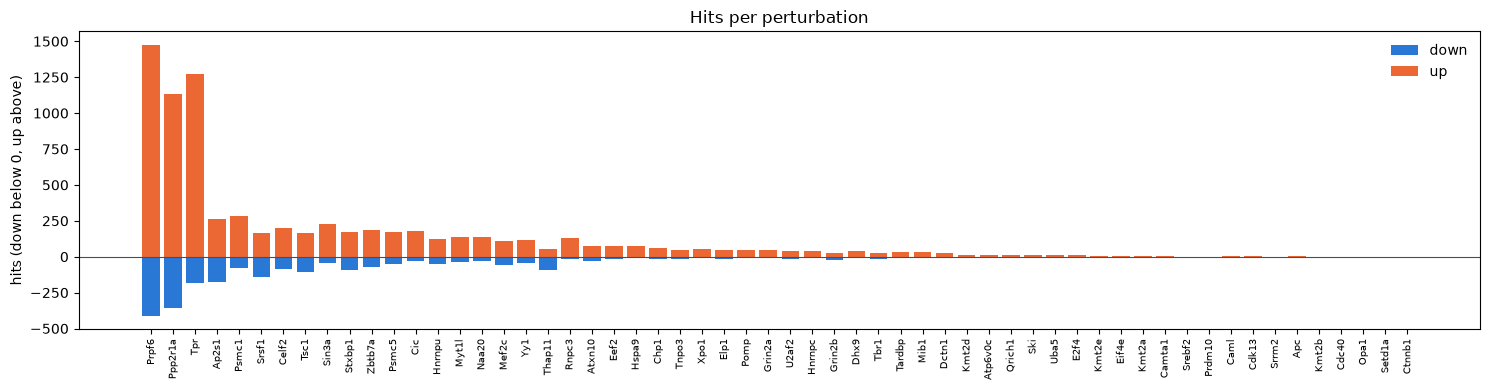

Spearman correlation of hits with arm size: 0.02


In [5]:
tested = df[np.isfinite(df['stat'])].copy()
tested['hit'] = tested['padj'] < Q
hits = tested[tested['hit']]

display(pd.Series({
    'gene x perturbation pairs tested': len(tested),
    'hits': len(hits),
    'perturbations with >= 1 hit': f"{hits['trt'].nunique()} / {A.shape[1]}",
    'hits that are down-regulated': f"{(hits['tau'] < 0).mean():.0%}",
    'hits with zero counts in the perturbed arm': int((hits['count_treated'] == 0).sum()),
    'median |tau| of hits': round(hits['tau'].abs().median(), 2),
}, name=TAG).to_frame())

per_pert = pd.DataFrame({
    'down': hits[hits['tau'] < 0].groupby('trt').size(),
    'up': hits[hits['tau'] > 0].groupby('trt').size(),
}).reindex(A.columns).fillna(0).astype(int)
per_pert['hits'] = per_pert.sum(1)
per_pert['cells'] = n_pert.reindex(per_pert.index).astype(int)
per_pert = per_pert.sort_values('hits', ascending=False)

fig, ax = plt.subplots(figsize=(15, 4))
x = np.arange(len(per_pert))
ax.bar(x, -per_pert['down'], color=BLUE, label='down')
ax.bar(x, per_pert['up'], color=ORANGE, label='up')
ax.axhline(0, color='0.3', lw=0.8)
ax.set_xticks(x, per_pert.index, rotation=90, fontsize=7)
ax.set_ylabel('hits (down below 0, up above)'); ax.legend(frameon=False)
ax.set_title('Hits per perturbation')
plt.tight_layout(); plt.show()
print(f"Spearman correlation of hits with arm size: "
      f"{stats.spearmanr(per_pert['hits'], per_pert['cells']).statistic:.2f}")

**Conclusion.** causarray finds 9,981 hits in 56 of the 58 perturbations, none of them from an arm with zero counts of the gene. Three quarters are up-regulated. The number of hits does not follow the number of cells (Spearman 0.02; the arms have 68–227 cells), so a perturbation's hit count reflects how strongly it changes expression. Three perturbations stand apart, Prpf6, Ppp2r1a and Tpr with about 1,500–1,900 hits each, followed by Ap2s1 (439), Psmc1 (360) and Srsf1 (304).

## 4. Check calibration on fake perturbations

Before reading the effects biologically, check that the test is honest on this
cell type. Take control cells only and label random subsets of them as fake
perturbations, with sizes drawn from the real arms (68–227 cells); each random
draw (seed) gives 10. Nothing differs between the arms, so every hit is false,
the test statistics should look like N(0, 1), and the p-values should be flat.
Wilcoxon on the same fake labels and genes is shown for reference.

### Why `min_counts = 20`

With the package default (`min_counts = 5`) a few false hits appear in genes that
are nearly absent from these neurons, where a handful of stray counts in 100
cells gives a large fold change. The table applies each threshold to the same
fake perturbations (seeds 0–2) and to the real ones.

In [6]:
from statsmodels.stats.multitest import multipletests

def load_null(seeds, lfc_dir):
    ca = pd.concat([pd.read_csv(f'{lfc_dir}/null/seed{s}.csv') for s in seeds], ignore_index=True)
    wc = pd.concat([pl.wilcoxon_table(f'results/{TAG}/null/wilcoxon_seed{s}.h5ad') for s in seeds],
                   ignore_index=True)
    ca = ca[np.isfinite(ca['stat'])]
    return ca.merge(wc, on=['trt', 'gene_names'], how='left')

def apply_min_counts(d, mc):
    """Keep pairs passing LFC's expression threshold at min_counts=mc, then redo BH per perturbation."""
    d = d[np.isfinite(d['stat'])].copy()
    thr = mc / np.minimum(d['n_treated'], d['n_control'])
    observed = np.maximum(d['count_treated'] / d['n_treated'], d['count_control'] / d['n_control'])
    d = d[(np.maximum(d['mean_control'], d['mean_treated']) >= thr) & (observed >= thr)].copy()
    d['padj'] = d.groupby('trt')['pvalue'].transform(lambda p: multipletests(p, method='fdr_bh')[1])
    return d

null5 = load_null([0, 1, 2], f'results/{TAG}/min_counts5')
real5 = pd.read_csv(f'results/{TAG}/min_counts5/lfc.csv')
rows = []
for mc in (5, 10, 20, 40):
    n, r = apply_min_counts(null5, mc), apply_min_counts(real5, mc)
    fh = n[n['padj'] < Q]
    rows.append({'min_counts': mc,
                 'fake: false hits (30 arms)': len(fh),
                 'fake: false hits in genes < 0.05 counts/control cell': int((fh['mean_control'] < 0.05).sum()),
                 'real: hits': int((r['padj'] < Q).sum())})
display(pd.DataFrame(rows).set_index('min_counts'))

,fake: false hits (30 arms),fake: false hits in genes < 0.05 counts/control cell,real: hits
min_counts,,,
5,54,30,10514
10,32,12,10236
20,21,2,9981
40,11,1,9653


**Conclusion.** With the default, 30 of the 54 false hits sit in genes with fewer than 0.05 counts per control cell, mostly glial and immune genes that are nearly absent from these neurons. `min_counts = 20` removes those (2 left) and cuts the false hits overall by more than half (54 → 21), at the cost of 5% of the real hits (10,514 → 9,981). Raising it further gains little. **The pipeline uses `min_counts = 20` for all cell types.**

### Calibration at `min_counts = 20`, on fake perturbations not used to choose it

,false hits (30 fake arms),fraction p < 0.05 (target 0.05)
causarray,14,0.058
Wilcoxon,99,0.052


causarray z under the null: mean 0.02, SD 1.03 (target 0 and 1)


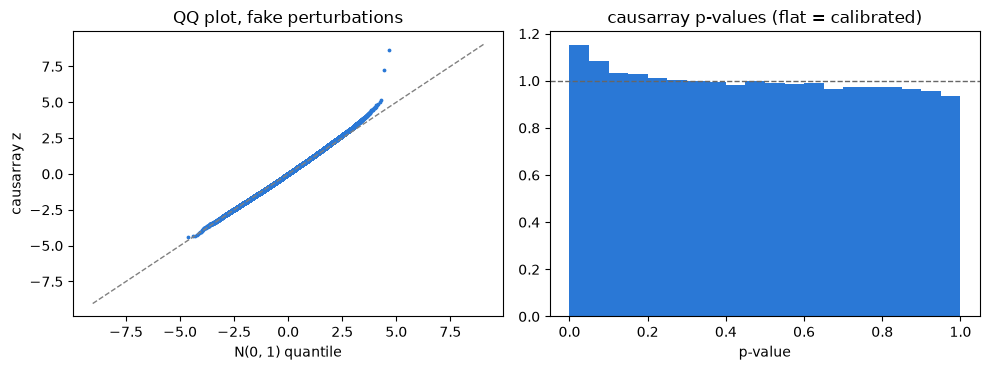

In [7]:
null20 = load_null([3, 4, 5], f'results/{TAG}')
display(pd.DataFrame({
    'false hits (30 fake arms)': [int((null20['padj'] < Q).sum()), int((null20['wilcox_padj'] < Q).sum())],
    'fraction p < 0.05 (target 0.05)': [round((null20['pvalue'] < 0.05).mean(), 3),
                                        round((null20['wilcox_pvalue'] < 0.05).mean(), 3)],
}, index=['causarray', 'Wilcoxon']))
print(f"causarray z under the null: mean {null20['stat'].mean():.2f}, SD {null20['stat'].std():.2f} (target 0 and 1)")

z = np.sort(null20['stat'].to_numpy())
theo = stats.norm.ppf((np.arange(1, len(z) + 1) - 0.5) / len(z))
bins = np.linspace(0, 1, 21)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].scatter(theo, z, s=3, color=BLUE, rasterized=True)
lim = max(abs(theo).max(), abs(z).max()) * 1.05
axes[0].plot([-lim, lim], [-lim, lim], color='0.5', lw=1, ls='--')
axes[0].set_xlabel('N(0, 1) quantile'); axes[0].set_ylabel('causarray z')
axes[0].set_title('QQ plot, fake perturbations')
axes[1].hist(null20['pvalue'].dropna(), bins=bins, color=BLUE, density=True)
axes[1].axhline(1, color='0.4', lw=1, ls='--')
axes[1].set_xlabel('p-value'); axes[1].set_title('causarray p-values (flat = calibrated)')
plt.tight_layout(); plt.show()

**Conclusion.** On fake perturbations that were not used to choose the threshold, causarray makes 14 false hits over 30 fake arms, about one every two arms, while Wilcoxon makes 99 on the same genes. For scale, a real perturbation here averages about 170 hits. The statistics are close to N(0, 1) (mean 0.02, SD 1.03) and 5.8% of p-values fall below 0.05. The QQ plot shows the only departure, a slightly heavy upper tail (the 99th percentile of z is 2.50 against 2.33, and all 14 false hits are up-regulated calls), which is what to watch in other cell types; the QC table in section 7 reports it.

## 5. What the screen shows

### 5a. Which perturbations share a response

Two perturbations that act through the same pathway should move the same genes
in the same direction. The heatmap correlates `tau` between perturbations over
the genes that are a hit for at least one of them (perturbations with at least
50 hits).

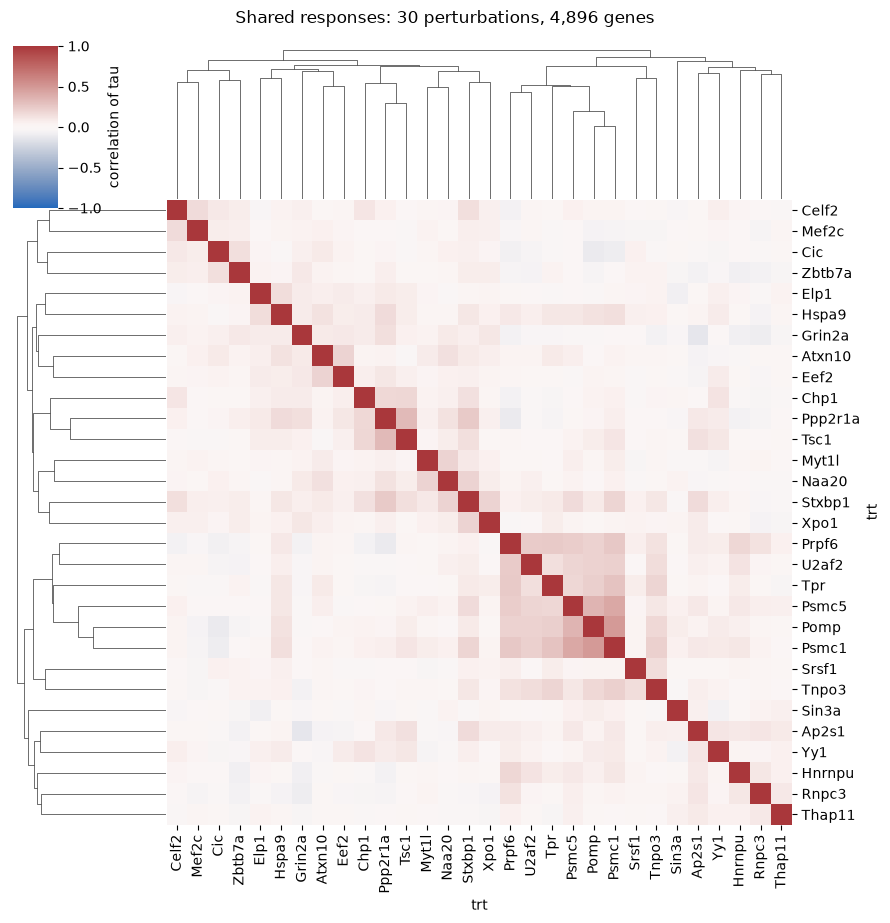

most similar pairs:


,,correlation of tau
trt,trt,
Pomp,Psmc1,0.49
Psmc1,Psmc5,0.41
Pomp,Psmc5,0.35
Ppp2r1a,Tsc1,0.33
Psmc1,Tpr,0.28
Prpf6,Psmc1,0.25
Ppp2r1a,Stxbp1,0.25
Prpf6,Tpr,0.24


In [8]:
strong = per_pert.index[per_pert['hits'] >= 50].tolist()
hit_genes = hits['gene_names'].unique()
T = (tested[tested['trt'].isin(strong) & tested['gene_names'].isin(hit_genes)]
     .pivot(index='gene_names', columns='trt', values='tau').dropna())
C = T.corr()
g = sns.clustermap(C, cmap='vlag', vmin=-1, vmax=1, figsize=(9, 9),
                   cbar_kws={'label': 'correlation of tau'})
g.fig.suptitle(f'Shared responses: {len(strong)} perturbations, {len(T):,} genes', y=1.02)
plt.show()

upper = C.where(np.triu(np.ones(C.shape, dtype=bool), k=1)).stack().sort_values(ascending=False)
print('most similar pairs:')
display(upper.head(8).round(2).to_frame('correlation of tau'))

**Conclusion.** The clearest module is the proteasome: its subunits Pomp, Psmc1 and Psmc5 give the three most similar responses (correlation 0.35–0.49), as expected for parts of one complex. In the clustered heatmap they form one block with the RNA-processing perturbations Prpf6, U2af2 (another splicing factor) and Tpr (pairwise correlations 0.24–0.28 with Psmc1), so disrupting protein turnover and RNA processing moves a common set of genes. Separately, Ppp2r1a (the PP2A scaffold) resembles Tsc1 (0.33) and Stxbp1 (0.25). Most other pairs are only weakly related, so each perturbation largely has its own profile.

### 5b. Genes that many perturbations move

A gene hit by many perturbations is part of a common response of these neurons,
rather than a target of one pathway.

In [9]:
by_gene = hits.groupby('gene_names').agg(
    perturbations=('trt', 'nunique'),
    fraction_down=('tau', lambda t: round((t < 0).mean(), 2)),
    median_tau=('tau', lambda t: round(t.median(), 2)),
).sort_values('perturbations', ascending=False)
print(f"genes hit by >= 10 perturbations: {(by_gene['perturbations'] >= 10).sum()} "
      f"(of {len(by_gene):,} genes with any hit)")
display(by_gene.head(20))

genes hit by >= 10 perturbations: 12 (of 5,861 genes with any hit)


,perturbations,fraction_down,median_tau
gene_names,,,
Scube1,14,0.93,-0.27
Snhg11,14,0.57,-0.04
Ahi1,12,0.92,-0.23
Atp1a1,12,1.00,-0.15
Rsrp1,12,0.50,-0.01
R3hdm1,11,0.73,-0.14
Adgrb1,11,0.73,-0.11
Amy1,11,0.18,0.34
Coro6,10,0.60,-0.25


**Conclusion.** Few genes respond to many perturbations: 12 of the 5,861 genes with any hit are hit by 10 or more. Among them, the activity-regulated neurotrophin Bdnf and the neuropeptide Adcyap1 (PACAP) go up in most of the perturbations that hit them, while the sodium pump subunit Atp1a1 and Scube1 and Ahi1 go down. This suggests a common response of these neurons to disruption, on top of each perturbation's specific effects; the correlations in 5a stay low because this shared part is small.

### 5c. What the strongest perturbations change

Enrichr (GO Biological Process, KEGG, Reactome) on the down- and up-regulated
hits of the four perturbations with the most hits, separately.

In [10]:
import re, time, requests
from pathlib import Path

ENRICH_DIR = Path('results') / TAG / 'enrichr'
ENRICH_DIR.mkdir(parents=True, exist_ok=True)
LIBS = ('GO_Biological_Process_2023', 'KEGG_2019_Mouse', 'Reactome_2022')

def enriched_terms(genes, cache_name):
    """Enrichr terms with adjusted p < 0.05 (cached per gene list; delete the cache if the list changes)."""
    path = ENRICH_DIR / f'{cache_name}.csv'
    if path.exists():
        return pd.read_csv(path)
    rows = []
    genes = list(genes)
    if len(genes) >= 5:
        r = requests.post('https://maayanlab.cloud/Enrichr/addList',
                          files={'list': (None, '\n'.join(genes)), 'description': (None, cache_name)}, timeout=60)
        r.raise_for_status()
        uid = r.json()['userListId']
        for lib in LIBS:
            for attempt in range(3):
                try:
                    e = requests.get('https://maayanlab.cloud/Enrichr/enrich',
                                     params={'userListId': uid, 'backgroundType': lib}, timeout=60)
                    e.raise_for_status()
                    break
                except requests.RequestException:
                    time.sleep(2)
            rows += [{'lib': lib, 'term': re.sub(r' \(GO:\d+\)| R-HSA-\d+', '', t[1]), 'padj': t[6]}
                     for t in e.json().get(lib, []) if t[6] < 0.05]
    out = pd.DataFrame(rows, columns=['lib', 'term', 'padj']).sort_values('padj')
    out.to_csv(path, index=False)
    return out

FOCUS = per_pert.index[:4].tolist()
rows = []
for trt in FOCUS:
    h = hits[hits['trt'] == trt]
    for direction, genes in (('down', h.loc[h['tau'] < 0, 'gene_names']),
                             ('up', h.loc[h['tau'] > 0, 'gene_names'])):
        terms = enriched_terms(genes, f'{trt}_{direction}')
        rows.append({'perturbation': trt, 'direction': direction, 'genes': len(genes),
                     'enriched terms': len(terms),
                     'top terms': '; '.join(f"{t[:45]} [{p:.0e}]" for t, p in
                                            terms[['term', 'padj']].head(3).itertuples(index=False))
                                  or '(none)'})
with pd.option_context('display.max_colwidth', 160):
    display(pd.DataFrame(rows).set_index(['perturbation', 'direction']))

genes  enriched terms  \
perturbation direction                          
Prpf6        down         412             164   
             up          1475             707   
Ppp2r1a      down         355             137   
             up          1131               4   
Tpr          down         184              42   
             up          1273             279   
Ap2s1        down         173              83   
             up           266               8   

                                                                                                                                                                top terms  
perturbation direction                                                                                                                                                     
Prpf6        down                                          Neuronal System [4e-19]; Transmission Across Chemical Synapses [9e-11]; Chemical Synaptic Transmission [1e-09]  
             up                                   Metabolism Of RNA [2e-60]; Processing Of Capped Intron-Containing Pre-mR [4e-43]; mRNA Splicing - Major Pathway [5e-35]  
Ppp2r1a      down                                                      Neuronal System [5e-08]; Signaling By NTRKs [5e-06]; Transmission Across Chemical Synapses [2e-05]  
             up                                                     Neuronal System [2e-06]; Protein-protein Interactions At Synapses [2e-02]; Potassium Channels [2e-02]  
Tpr          down                                               Neuronal System [3e-04]; Regulation Of Neuron Projection Development [6e-03]; Ca-dependent Events [1e-02]  
             up                                               Gene Expression (Transcription) [1e-12]; RNA Polymerase II Transcription [3e-10]; Metabolism Of RNA [6e-10]  
Ap2s1        down                                       Nuclear Events (Kinase And Transcription Fact [5e-08]; Signaling By NTRK1 (TRKA) [1e-06]; Neuronal System [1e-06]  
             up         Regulation Of Potassium Ion Transport [4e-02]; Positive Regulation Of Developmental Growth [4e-02]; Positive Regulation Of Axon Extension [4e-02]

**Conclusion.** Prpf6 and Tpr up-regulate their own machinery, and Prpf6, Tpr and Ppp2r1a down-regulate neuronal programs:

* **Prpf6** (spliceosome): up-regulated genes enrich for RNA metabolism and mRNA splicing (p = 2e-60); down-regulated genes for the neuronal system and synaptic transmission (4e-19).
* **Tpr** (nuclear pore): up for transcription and RNA polymerase II (1e-12); down for the neuronal system and neuron projection development.
* **Ppp2r1a** (PP2A): down for the neuronal system and neurotrophin (NTRK) signalling; its many up-regulated genes enrich only weakly (4 terms).
* **Ap2s1** (AP-2 adaptor, which internalizes receptors): down for kinase and transcription-factor signalling and NTRK1 (TrkA) signalling, consistent with the role of endocytosis in neurotrophin receptor signalling.

The up-regulation of splicing and transcription genes after knocking down those very processes looks like a compensatory response; the shared loss of synaptic genes fits the common response in 5b.

## 6. Wilcoxon as a reference

Wilcoxon on log-normalized counts is the usual first look at such a screen. It
does not adjust for the latent factors, so the two lists are not expected to
match, but most Wilcoxon hits should be found again and shared hits should move
in the same direction. The comparison uses the genes causarray tests.

,L45Glut
causarray hits,9981
Wilcoxon hits,5322
Wilcoxon hits also found by causarray,82%
shared hits with the same direction,100%
correlation of effect sizes (all tested pairs),0.93


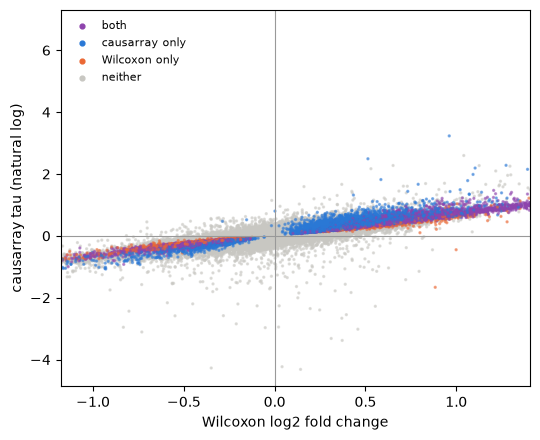

In [11]:
df_wc = pl.run_wilcoxon(TAG)
cmp = tested.merge(df_wc, on=['trt', 'gene_names'], how='inner')
cmp['wc'] = cmp['wilcox_padj'] < Q
both = cmp['hit'] & cmp['wc']
display(pd.Series({
    'causarray hits': int(cmp['hit'].sum()),
    'Wilcoxon hits': int(cmp['wc'].sum()),
    'Wilcoxon hits also found by causarray': f"{both.sum() / cmp['wc'].sum():.0%}",
    'shared hits with the same direction': f"{(np.sign(cmp.loc[both, 'tau']) == np.sign(cmp.loc[both, 'wilcox_logfc'])).mean():.0%}",
    'correlation of effect sizes (all tested pairs)': round(cmp[['tau', 'wilcox_logfc']].corr().iloc[0, 1], 2),
}, name=TAG).to_frame())

fig, ax = plt.subplots(figsize=(5.5, 4.5))
c = cmp.iloc[np.argsort((cmp['hit'] | cmp['wc']).to_numpy(), kind='stable')]
colors = np.select([c['hit'] & c['wc'], c['hit'], c['wc']], [PURPLE, BLUE, ORANGE], GREY)
ax.scatter(c['wilcox_logfc'], c['tau'], c=colors, s=2, alpha=0.5, rasterized=True)
ax.axhline(0, color='0.6', lw=0.8); ax.axvline(0, color='0.6', lw=0.8)
ax.set_xlim(np.nanpercentile(c['wilcox_logfc'], [0.05, 99.95]))
ax.set_xlabel('Wilcoxon log2 fold change'); ax.set_ylabel('causarray tau (natural log)')
for col, lab in ((PURPLE, 'both'), (BLUE, 'causarray only'), (ORANGE, 'Wilcoxon only'), (GREY, 'neither')):
    ax.scatter([], [], color=col, s=12, label=lab)
ax.legend(frameon=False, fontsize=8, loc='upper left')
plt.tight_layout(); plt.show()

**Conclusion.** The two methods agree where Wilcoxon finds something: causarray recovers 82% of the Wilcoxon hits, every shared hit moves in the same direction, and effect sizes correlate at 0.93. causarray finds about twice as many hits (9,981 vs 5,322), and in the calibration check of section 4 causarray made fewer false hits than Wilcoxon on fake perturbations (14 against 99). That check does not show that every extra hit is real, so the checks below look at what the extra hits contain.

### Which method's extra hits carry biology?

Shared hits say nothing about which method is better, so the checks below look
at the hits only one method calls, for the same four perturbations as in 5c:

* **Exclusive hits.** Enrich the causarray-only and the Wilcoxon-only genes
  separately. Noise should not enrich for anything.
* **Lists of equal length.** Longer lists give more enriched terms whatever their
  quality, so also take each method's top *k* genes, with the same *k* (the
  smaller of the two hit counts), and count the terms.
* **Expression support.** Are each method's exclusive hits well-measured genes,
  or sparse ones where a few counts decide the call?

In [12]:
rows = []
for trt in FOCUS:
    g = cmp[cmp['trt'] == trt]
    k = int(min(g['hit'].sum(), g['wc'].sum()))
    sets = {
        'causarray only': g.loc[g['hit'] & ~g['wc'], 'gene_names'],
        'Wilcoxon only': g.loc[g['wc'] & ~g['hit'], 'gene_names'],
        f'causarray top {k}': g[g['hit']].sort_values('pvalue')['gene_names'].head(k),
        f'Wilcoxon top {k}': g[g['wc']].sort_values('wilcox_pvalue')['gene_names'].head(k),
    }
    for name, genes in sets.items():
        terms = enriched_terms(genes, f"{trt}_{name.replace(' ', '_')}")
        go = terms[terms['lib'] == 'GO_Biological_Process_2023']
        rows.append({'perturbation': trt, 'gene list': name, 'genes': len(genes),
                     'enriched terms': len(terms), 'GO BP terms': len(go),
                     'top GO BP term': f"{go.iloc[0]['term'][:55]} [{go.iloc[0]['padj']:.0e}]" if len(go) else '(none)'})
with pd.option_context('display.max_colwidth', 80):
    display(pd.DataFrame(rows).set_index(['perturbation', 'gene list']))

ca_only, wc_only = cmp['hit'] & ~cmp['wc'], cmp['wc'] & ~cmp['hit']
display(pd.DataFrame({
    'hits': [int(ca_only.sum()), int(wc_only.sum())],
    'median counts in the perturbed arm': [cmp.loc[ca_only, 'count_treated'].median(),
                                           cmp.loc[wc_only, 'count_treated'].median()],
    'median counts per control cell': [round(cmp.loc[ca_only, 'mean_control'].median(), 2),
                                       round(cmp.loc[wc_only, 'mean_control'].median(), 2)],
}, index=['causarray only', 'Wilcoxon only']))

genes  enriched terms  GO BP terms  \
perturbation gene list                                                
Prpf6        causarray only       1379             458          141   
             Wilcoxon only          31               0            0   
             causarray top 539     539             280           96   
             Wilcoxon top 539      539             100           33   
Ppp2r1a      causarray only        583               0            0   
             Wilcoxon only         176               1            0   
             causarray top 1079   1079             107           46   
             Wilcoxon top 1079    1079             141           76   
Tpr          causarray only        773             225           67   
             Wilcoxon only          63               0            0   
             causarray top 747     747             102           59   
             Wilcoxon top 747      747              52           39   
Ap2s1        causarray only        252               0            0   
             Wilcoxon only          20               0            0   
             causarray top 207     207              55           13   
             Wilcoxon top 207      207              32            9   

                                                                           top GO BP term  
perturbation gene list                                                                     
Prpf6        causarray only                                       mRNA Processing [4e-15]  
             Wilcoxon only                                                         (none)  
             causarray top 539                     mRNA Splicing, Via Spliceosome [1e-15]  
             Wilcoxon top 539                      mRNA Splicing, Via Spliceosome [8e-09]  
Ppp2r1a      causarray only                                                        (none)  
             Wilcoxon only                                                         (none)  
             causarray top 1079                    Chemical Synaptic Transmission [8e-07]  
             Wilcoxon top 1079                     Chemical Synaptic Transmission [9e-06]  
Tpr          causarray only                       Peptidyl-Serine Phosphorylation [3e-04]  
             Wilcoxon only                                                         (none)  
             causarray top 747   Regulation Of Transcription By RNA Polymerase II [7e-08]  
             Wilcoxon top 747                      mRNA Splicing, Via Spliceosome [7e-05]  
Ap2s1        causarray only                                                        (none)  
             Wilcoxon only                                                         (none)  
             causarray top 207                         Neurotransmitter Secretion [4e-04]  
             Wilcoxon top 207                          Nervous System Development [3e-03]

,hits,median counts in the perturbed arm,median counts per control cell
causarray only,5622,170.0,1.17
Wilcoxon only,963,135.0,1.00


**Conclusion.** For two of the four perturbations, Prpf6 and Tpr, causarray's extra hits carry the biology and Wilcoxon's do not; for Ap2s1 neither method's do, and Ppp2r1a goes the other way:

* **Prpf6**: its 1,379 causarray-only genes enrich for mRNA processing and splicing (458 terms); its 31 Wilcoxon-only genes enrich for nothing. On lists of equal length causarray gives 280 terms against 100, with the same top term (mRNA splicing), at a stronger p-value (1e-15 against 8e-09).
* **Tpr**: 225 terms for the causarray-only genes, none for the Wilcoxon-only genes; on equal lists 102 against 52, and causarray's top term (transcription by RNA polymerase II) matches Tpr's role at the nuclear pore, while Wilcoxon's is splicing.
* **Ap2s1**: neither method's exclusive hits enrich; on equal lists causarray gives 55 terms against 32, led by neurotransmitter secretion.
* **Ppp2r1a is the exception**: its 583 causarray-only genes (mostly up-regulated) enrich for nothing, and on equal lists Wilcoxon gives slightly more terms (141 against 107), with the same top term (chemical synaptic transmission). Ppp2r1a's extra up-regulated hits have no annotated theme, so treat them with care.

Across all perturbations, causarray's exclusive hits are, if anything, better measured than Wilcoxon's (median 170 against 135 counts in the perturbed arm; 1.17 against 1.00 per control cell), so the extra hits are not sparse-gene artifacts. Together with the calibration check (14 false hits against 99), this suggests causarray's extra power is mostly real signal.

## 7. Running every cell type

The loop below is the whole analysis for all cell types. It is switched off
here (`RUN_ALL = False`). Every step skips work already on disk, so after a
crash the loop can simply be run again.

What it costs, measured on this cell type (22k cells, 14k genes, 58 perturbations),
with crispyx 0.1.6 (0.1.5 is several times slower):

* **latent factors**: one GCATE fit per cell type, 34 minutes on 32 cores;
* **causarray**: about 5 minutes per batch of 10 perturbations with all 15k controls, running 3 batches at a time on a 32-core, 512 GB machine. **Cap each job's threads when running several at once** (`export NUMBA_NUM_THREADS=10 OMP_NUM_THREADS=10 OPENBLAS_NUM_THREADS=10` for 3 jobs on 32 cores); otherwise the jobs compete for cores and run about ten times slower. A batch can use up to about 90 GB of memory;
* **Wilcoxon**: a few minutes for all perturbations;
* **calibration check**: 3 fake-perturbation batches (seeds 3–5), the same cost as 3 causarray batches.

On an Apple Silicon Mac, use a native (arm64) Python: an Intel Python running under Rosetta is several times slower, and `import causarray` warns about it.

For 1,900 perturbations a cell type has 190 batches. The batches are independent,
so run them as separate jobs, as many at a time as memory allows
(`python pipeline.py lfc --tag <tag> --batches <k>`), then call `pl.run_lfc`
once more to combine them. Memory grows with (cells in the batch) × (genes) ×
(batch size), so use `pl.run_lfc(..., batch_size=5)` for large cell types.

In [13]:
RUN_ALL = False
SRC = 'data/combined.h5ad'          # the full screen, one h5ad with all cell types
CELL_TYPES = {                       # tag -> value of obs['predicted_group']
    'L45Glut': '005 L4-5 IT CTX Glut',
    # 'L23Glut': '...',
}

def run_cell_type(tag, cell_type):
    pl.subset_cell_type(SRC, cell_type, tag)
    Y, A, X, X_A = pl.load_inputs(tag)
    res_2 = pl.fit_factors(tag, Y, X, A)
    df = pl.run_lfc(tag, Y, A, X, X_A, res_2)
    df_wc = pl.run_wilcoxon(tag)
    nulls = [pl.run_null(tag, Y, A, X, X_A, res_2, seed) for seed in (3, 4, 5)]
    return pl.summarize(tag, df, df_wc, nulls)

if RUN_ALL:
    qc = pd.DataFrame([run_cell_type(t, c) for t, c in CELL_TYPES.items()]).set_index('cell type')
else:                                # this cell type, from the cached results
    nulls = [(pd.read_csv(f'results/{TAG}/null/seed{s}.csv'),
              pl.wilcoxon_table(f'results/{TAG}/null/wilcoxon_seed{s}.h5ad')) for s in (3, 4, 5)]
    qc = pd.DataFrame([pl.summarize(TAG, df, df_wc, nulls)]).set_index('cell type')
display(qc.T)

cell type,L45Glut
perturbations,58.00
causarray hits,9981.00
Wilcoxon hits,5322.00
Wilcoxon hits recovered,0.82
fraction down,0.24
hits with zero perturbed counts,0.00
null: causarray false hits,14.00
null: Wilcoxon false hits,99.00
null: SD of z (target 1),1.03


**How to read the QC table.** One row per cell type; look for cell types that
stand out. For reference, this cell type gives:

* 9,981 hits, recovering 82% of the Wilcoxon hits, 24% down-regulated, no hits with zero counts in the perturbed arm;
* calibration check: 14 false hits against Wilcoxon's 99 over 30 fake perturbations, SD of z 1.03.

A cell type that fails the null check (many false hits, or SD of z well above 1)
should be looked at before its hits are used: start with its propensity check
(section 2), the arms the pipeline adjusted (`lfc_batches/*_propensity.csv`),
and the size of its arms.

## Summary

1. **How to run it.** One GCATE fit per cell type, then `LFC` on all controls plus 10 perturbations at a time, with `min_counts = 20` and threads capped when batches run in parallel. `pipeline.py` does each step and resumes after a crash.
2. **What to check before reading effects.** The propensity check (section 2): here only Tpr needed an adjustment, dropping library size for Tpr alone. The calibration check (section 4): about one false hit every two fake perturbations, with statistics close to N(0, 1).
3. **What this cell type shows.** 56 of 58 perturbations change expression; Prpf6, Ppp2r1a and Tpr change it most. Prpf6 and Tpr raise genes of their own machinery (splicing, transcription), and all three lower neuronal genes. The proteasome subunits Pomp, Psmc1 and Psmc5 form the clearest shared module, and activity-regulated genes such as Bdnf respond to many perturbations.
4. **Compared with Wilcoxon.** causarray recovers 82% of the Wilcoxon hits with the same directions and finds about twice as many. Its extra hits for Prpf6 and Tpr carry the expected biology while Wilcoxon's extra hits enrich for nothing; Ppp2r1a's extra hits are the exception.
5. **Next.** Run the loop in section 7 for the other cell types and compare their QC rows, then ask whether the modules and shared genes found here recur in other neuron types.